# Resume Screener

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/resume-screener/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/resume-screener/demo.ipynb)

> Rank a stack of resumes by skills fit - a triage aid, not a hiring decision.

HR can burn 40 hours a week on a first read of every resume. This tool does the
*mechanical* first pass - extract the job's required skills, score each resume on coverage
and experience, and rank them - so humans spend their time on judgement, not keyword
hunting.

> **Read this first.** Resume screening is high-stakes and bias-prone. This tool scores
> **only job-relevant skills and experience** - never name, gender, age, or any protected
> attribute. It is a triage aid: a human reviews every candidate, and nothing is ever
> auto-rejected.

**What this notebook covers**
1. Extracting required skills from a job description
2. Deterministic skill-overlap scoring (auditable, no LLM)
3. Ranking a batch of resumes
4. A score chart across candidates
5. The bias guardrails + the Claude upgrade
6. Try your own


## Step 1 - Extract required skills from the JD

Before scoring anything, we need the rubric: what does this role actually require? We pull
it from explicit "Required skills:" lines and inline "experience with X" phrases.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field


_WORD = re.compile(r"[a-z0-9+#.]+")
_REQ_HINT = re.compile(
    r"\b(experience with|proficient in|knowledge of|skilled in|familiar with|expertise in|using)\s+", re.I)


def _tokens(text):
    return set(_WORD.findall(text.lower()))


def extract_required_skills(job_desc):
    skills = []
    for line in job_desc.splitlines():
        line = line.strip(" -*\t")
        m = re.match(r"(?:required skills|skills|requirements|must have)\s*:\s*(.+)", line, re.I)
        if m:
            skills += [s.strip() for s in re.split(r"[,;/]", m.group(1)) if s.strip()]
    for m in _REQ_HINT.finditer(job_desc):
        tail = job_desc[m.end():m.end() + 40]
        phrase = re.split(r"[,.;\n]", tail)[0].strip()
        if 1 <= len(phrase.split()) <= 4:
            skills.append(phrase)
    seen, out = set(), []
    for s in skills:
        k = s.lower()
        if k and k not in seen and len(k) > 1:
            seen.add(k)
            out.append(s)
    return out[:15]


SAMPLE_JOB = """\
Senior Data Engineer

We are hiring a Senior Data Engineer to own our analytics platform.

Required skills: Python, SQL, Airflow, dbt, AWS, Snowflake

Responsibilities:
- Build and maintain ETL pipelines with experience with Spark
- Strong knowledge of data modeling and warehouse design
- 5+ years of experience in data engineering
"""

print("Required skills:", extract_required_skills(SAMPLE_JOB))


Required skills: ['Python', 'SQL', 'Airflow', 'dbt', 'AWS', 'Snowflake', 'Spark']


## Step 2 - Score one resume

Scoring is intentionally simple and auditable: 80% weight on how many required skills the
resume covers, 20% on a years-of-experience signal. A recruiter can read the math and
trust it - no black box.

In [2]:
@dataclass
class ScreenResult:
    score: int
    matched_skills: list = field(default_factory=list)
    missing_skills: list = field(default_factory=list)
    years_experience: float = None
    recommendation: str = ""
    rationale: str = ""

    def band(self):
        if self.score >= 70:
            return "advance"
        if self.score >= 45:
            return "maybe"
        return "reject"


def extract_years(resume):
    m = re.search(r"(\d{1,2})\+?\s*years?(?:\s+of)?\s+(?:experience|exp)", resume, re.I)
    return float(m.group(1)) if m else None


def heuristic_screen(resume, job_desc):
    required = extract_required_skills(job_desc)
    rt = _tokens(resume)
    matched = [s for s in required if _tokens(s) and _tokens(s) <= rt]
    missing = [s for s in required if s not in matched]
    skill_score = len(matched) / len(required) if required else 0.0
    years = extract_years(resume)
    years_score = min(years / 5.0, 1.0) if years else 0.0
    score = round(100 * (0.8 * skill_score + 0.2 * years_score))
    res = ScreenResult(score, matched, missing, years,
        rationale=f"Matched {len(matched)}/{len(required)} skills" +
                  (f"; {years:.0f} yrs experience." if years else "; no explicit years."))
    res.recommendation = res.band()
    return res


SAMPLE_RESUMES = {
    "Strong fit": "Data engineer with 6 years of experience building data platforms. "
                  "Skills: Python, SQL, Airflow, dbt, AWS, Snowflake, Spark, Terraform. "
                  "Built ETL pipelines processing 2TB/day and led data modeling for the warehouse.",
    "Partial fit": "Analytics engineer, 3 years of experience. "
                   "Skills: SQL, dbt, Python, Looker. Some exposure to AWS. "
                   "Built reporting models and dashboards for the marketing team.",
    "Weak fit": "Frontend developer with 4 years experience. "
                "Skills: JavaScript, React, CSS, Figma. Built customer-facing web apps.",
}

r = heuristic_screen(SAMPLE_RESUMES["Strong fit"], SAMPLE_JOB)
print(f"Score: {r.score}/100  ({r.recommendation})")
print("Matched:", r.matched_skills)
print("Missing:", r.missing_skills)
print("Rationale:", r.rationale)


Score: 100/100  (advance)
Matched: ['Python', 'SQL', 'Airflow', 'dbt', 'AWS', 'Snowflake', 'Spark']
Missing: []
Rationale: Matched 7/7 skills; 6 yrs experience.


## Step 3 - Rank the whole stack

Now run every resume through the same rubric and sort. This is the time-saver: HR opens
the ranked list and starts at the top, instead of reading 200 resumes cold.

In [3]:
results = [(name, heuristic_screen(text, SAMPLE_JOB)) for name, text in SAMPLE_RESUMES.items()]
results.sort(key=lambda x: x[1].score, reverse=True)

print(f"{'Candidate':<14}{'Score':<8}{'Band':<10}{'Missing skills'}")
print("-" * 60)
for name, res in results:
    print(f"{name:<14}{res.score:<8}{res.recommendation:<10}{', '.join(res.missing_skills) or '-'}")


Candidate     Score   Band      Missing skills
------------------------------------------------------------
Strong fit    100     advance   -
Partial fit   46      maybe     Airflow, AWS, Snowflake, Spark
Weak fit      16      reject    Python, SQL, Airflow, dbt, AWS, Snowflake, Spark


## Step 4 - Visualize the ranking

A single chart shows where each candidate lands against the advance / maybe / reject
thresholds - and makes the borderline "maybe" cases (the ones humans must look at)
obvious.

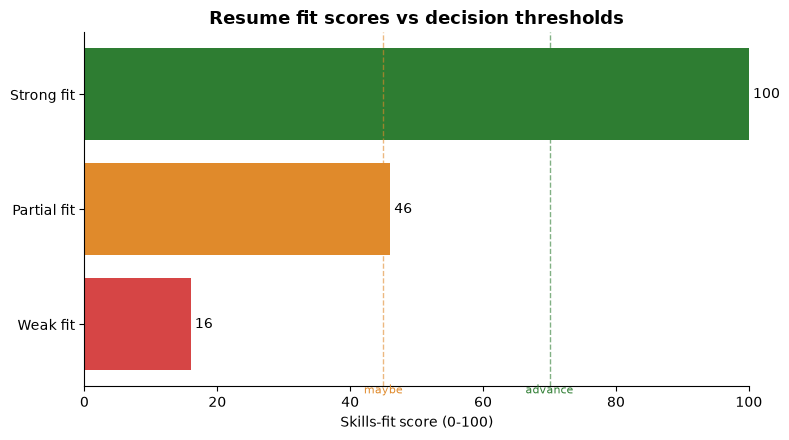

In [4]:
import matplotlib.pyplot as plt

names = [n for n, _ in results]
scores = [res.score for _, res in results]
band_color = {"advance": "#2e7d32", "maybe": "#e08a2b", "reject": "#d64545"}
colors = [band_color[res.recommendation] for _, res in results]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(names[::-1], scores[::-1], color=colors[::-1])
ax.axvline(70, color="#2e7d32", ls="--", lw=1, alpha=0.6)
ax.axvline(45, color="#e08a2b", ls="--", lw=1, alpha=0.6)
ax.set_xlim(0, 100)
ax.set_title("Resume fit scores vs decision thresholds", fontsize=13, weight="bold")
ax.set_xlabel("Skills-fit score (0-100)")
ax.bar_label(bars, padding=3)
ax.text(70, -0.6, "advance", color="#2e7d32", fontsize=8, ha="center")
ax.text(45, -0.6, "maybe", color="#e08a2b", fontsize=8, ha="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("scores.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary & guardrails

| Candidate | Score | Band |
|-----------|-------|------|
| Strong fit | 100 | advance |
| Partial fit | 46 | maybe |
| Weak fit | 16 | reject |

**The point of the bands:** "advance" and "reject" are easy; the value is flagging
**"maybe"** for a human to read carefully.

**Bias guardrails baked in:**
- Scores use **skills + experience only** - the code never reads name, gender, age, school prestige, or any protected signal.
- The math is **auditable** - a recruiter can see exactly why a score is what it is.
- **No auto-reject.** Every candidate is reviewed by a human; the tool ranks, it does not decide.

In [5]:
# --- Upgrade to Claude (optional) ---
# import os, json, anthropic
#
# def llm_screen(resume, job_desc, api_key):
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(model="claude-sonnet-4-5", max_tokens=1200,
#         messages=[{"role": "user", "content":
#             "Score this resume vs the JD on skills/experience ONLY. Ignore name, gender, "
#             "age, and all protected attributes. Return JSON.\n"
#             f"JOB:\n{job_desc}\n\nRESUME:\n{resume}"}])
#     d = json.loads(resp.content[0].text)
#     return ScreenResult(d["score"], d["matched_skills"], d["missing_skills"],
#                         d.get("years_experience"), d["recommendation"], d["rationale"])
#
# # Claude reads "led data modeling" as evidence of warehouse-design skill even when the
# # exact JD keyword is absent - catching fits the keyword scorer misses.


In [6]:
# --- Try your own ---
# my_job = """Required skills: ...\n5+ years of experience..."""
# my_resume = """..."""
# res = heuristic_screen(my_resume, my_job)
# print(res.score, res.recommendation, "| missing:", res.missing_skills)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 36 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version screens a batch of resumes, ranks them, shows matched/missing skills
per candidate, and keeps the "human-in-the-loop, no auto-reject" warning front and center.